# **STAGE 1 - ETL**

## **Objectives**

In this Jupyter Notebook, I will be following the ETL process on the raw dataset: `student_performance_dataset.csv`

The process will be as follows:
* **Extract**: I will load the dataset into a pandas DataFrame and perform an initial inspection of its structure, data types and quality.
* **Transform**: I will clean and standardise the dataset, change data types where necessary, remove any null values, and engineer new features.
* **Load**: Finally, I will export the cleaned DataFrame as a new CSV file, ready to be used in the next Jupyter Notebook - **Stage 2 - Visualisation**.

## **Inputs**

* Write down which data or information you need to run the notebook 

## **Outputs**

* Write here which files, code or artefacts you generate by the end of the notebook 

## **Additional Comments**

* If you have any additional comments that don't fit in the previous bullets, please state them here. 

---

## **Change working directory**

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/student-performance-analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/student-performance-analysis'

---

## **Import Libraries and Packages**

In order to read `student_performance_dataset.csv` and create visualisations for exploratory analysis, I need to install the following libraries and packages:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

---

## **Core Statistical Concepts**

Before diving into this project, I am first going to outline some key statistical concepts that are foundational to data analysis. Because many of these will appear in my project, it is important to outline what they mean and how they are used.

I'll split these up into three main sections: 

### **Descriptive Statistics**
Descriptive statistics summarise features of a data set. They can describe things like the **central tendency** and the **variability**.

| **Concept** | **Sub-Concept** | **Description** |
| ---------- | --------------| -------- |
| **Central Tendency** | - | The central tendency refers to a value that shows the middle or typical point in a dataset. |
| - | **Mean** | The mean is the average value of a dataset. <br><br>***How to Calculate***: Add all the values together and divide by the total number of observations. <br><br>***Pandas method to calculate***: Use `.mean()`. <br><br> The mean provides a simple measure of the central tendency of the data, although it can be strongly affected by unusually large or small values (outliers). |
| - | **Median** | The median is the middle value - it can be thought of as the element that divides the data into two equal parts. <br><br>***How to Calculate***: Arrange the data in ascending or descending order. If the number of elements is odd, the median is the middle element in the arranged values. If the number of observations is even, the median is given by the mean of the two middle elements. <br><br>***Pandas method to calculate***: Use `.median()`. <br><br>Unlike the mean, the median is less affected by outliers, making it useful for datasets with skewed distributions. |
| - | **Mode** | The mode is the value that appears most often (has the highest frequency) in a dataset. <br><br>***How to Calculate***: The easiest way is to order the numbers in ascending or descending order. Then, count the number of times a value appears. <br><br>***Pandas method to Calculate***: Use `.mode()`. <br><br>A dataset can be **Uni-modal** (only one mode), **Bi-modal** (two modes), or **Multi-modal** (more than two modes). |
| **Variability** | - | Measures of variability are also known as dispersion or spread and show how spread out the data is. Some of the ways to measure this are **standard deviation**, **range** and **variance**. |
| - | **Standard Deviation** | Standard deviation measures how spread out the observations are around the mean. It is used by data analysts to assess the distribution of the data. A small standard deviation means values tend to be close to the mean. A large standard deviation indicates greater variability. |

### **Inferential Statistics**
Whereas descriptive statistics summarise the data you have, inferential statistics use data to draw conclusions beyond the observed sample.

| **Concept** | **Sub-Concept** | **Description** |
| ---------- | --------------| -------- |
| **Hypothesis Testing** | - | This is a statistical method used to determine whether there is sufficient evidence to support a claim. <br><br> A **null hypothesis (H0)** represents no effect or difference, and an **alternative hypothesis (Ha or H1)**, which represents an effect or difference. A statistical test and a significance level are then used to determine whether the evidence is strong enough to reject the null hypothesis. |

### **Probability**
Statistical probability measures how likely an event is to occur and is expressed as a number between 0 and 1.

| **Concept** | **Sub-Concept** | **Description** |
| ---------- | --------------| -------- |
| **p-value** | - | The p-value is a statistical measure and specific probability that tells you the likelihood that an observed outcome is the result of chance or that it could have occurred under the null hypothesis. It tells you whether a result is **statistically significant**. |

### **Why are these core concepts so important in Data Analysis?**
All of the concepts listed together are the foundation of data analysis. They help to transform raw data into meaningful information and help to support evidence-based decision-making.

---

## **1. Extraction**

In this first section, Extraction, I am looking to gain a baseline understanding of what my data looks like before I move on to cleaning and transforming.

I am using the acronym - **DISH** - to guide this process, where the letters stand for:

| Letter | Function / Attribute |
| ------ | ------- |
|**D**| `.describe`|
|**I**| `.info()`|
|**S**| `.shape`|
|**H**| `.head()`|

I will also use the following extraction steps:

| Function / Attribute |
| -----|
|`.dtypes`|
|`.isnull.sum()`|

### **1.1 Load the raw dataset**

Firstly, I will load the raw dataset - `student_performance_dataset.csv` - that I am going to be working on for this ETL Jupyter Notebook.

In [5]:
# Load the raw dataset
df_raw = pd.read_csv("datasets/raw-data/student_performance_dataset.csv")

# Display the first few rows of the dataset to make sure the data has loaded correctly
df_raw.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


### **1.2 Display the shape of the dataset**

In [6]:
# Display the shape of the dataset
print(f"Shape of the dataset: {df_raw.shape}")

Shape of the dataset: (1000, 12)


The dataset has 1,000 rows and 12 columns.

### **1.3 Display the data types for each column**

Now, I am going to inspect the data types for each column of my dataframe.

In [7]:
# Outline the data types of each column in the dataset
print(f"Data types of each column:\n{df_raw.dtypes}")

Data types of each column:
student_id                      int64
gender                         object
study_time_hours              float64
attendance_percent            float64
sleep_hours                   float64
parental_education             object
internet_access                object
extracurricular_activities     object
part_time_job                  object
previous_grade                float64
final_exam_score              float64
final_grade                    object
dtype: object


### **1.4 Display a summary of all columns in the dataset**

In [8]:
# Use .info() to get a concise summary of the dataset, including the number of non-null entries
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


This method builds on what we have already established using `.shape` and `.dtypes`. 

It shows us that we have 1000 entries and 12 data columns and the data types for each of these columns. 

Additionally, we can see an insight into `Non-Null Count`, aka the number of values in each column that aren't null. 
* I will explore this further down in **1.6 Check for Missing Values in the Dataset**. 
* This summary of the dataset clearly shows that `parental_education` has missing values - `898 non-null` vs the expected `1000 non-null`.

### **1.5 Display summary statistics for the dataset**

In [9]:
# Use .describe() for summary statistics of the numerical columns in the dataset
df_raw.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


As you can see, `.describe()` shows some of the core descriptive statistics measures that I have described in more detail in **Core Statistical Concepts**. 

The `student_id` column shows a high standard deviation, meaning variability in the data is high. If we look again at first five rows of the dataset (using `.head()` above), we understand why: the values in `student_id` are `1`, `2`, `3`, `4`, `5...` and looking at the  max figure above, it goes all the way up to `1000`. These integers are acting like labels for each student and therefore this variability is explainable. 

There are no minus numbers included in any of the numerical columns and with a quick look over all of the figures, nothing seems particularly anomalous. I will look at the interquartile range and outlier detection in **2. Transform** if any outliers need handling.

#### **1.6 Check for Missing Values in the Dataset**

In [10]:
## Check for null values in the dataset
print(f"Number of null values in each column:\n{df_raw.isnull().sum()}")

Number of null values in each column:
student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64


We can see here that there are 102 null values listed for `parental_education`. We will need to inspect these further and transform them in the next section - **2. Transform**.

---

## **2. Transform**

In this next section, Transform, my aim is to convert my raw and extracted dataset into a clean, well-structured dataset that is feature-rich to support the hypotheses I will investigate in the **Stage 2 - Visualisation** Jupyter Notebook.

I will create a copy of my `df_raw` DataFrame so as not to transform the raw dataset.

In [11]:
df_etl = df_raw.copy()

### **2.1 Handling Missing Values**

As we saw in the previous section, there are 102 missing values for `parental_education` and I need to make a decision on how best to manage them.

I believe there are several options and I will outline the decision process regarding each:

#### **Option 1 - Delete the rows containing the missing data**

* With only 1,000 rows to start with, 102 rows accounts for 10.2% of the dataset.
* This means it would not be possible to delete these rows without substantially reducing the amount of data (and probably throwing away useful information in the process).

#### **Option 2 - Add a value to suggest that the parental education level is "Lower than High School"**

* This is making an assumption about what the NaN means that is not supported in the documentation found on Kaggle.
* There are so many things that NaN could represent:
    * The respondent didn't know their parents' education.
    * The question wasn't answered.
    * The data wasn't collected.
    * The parent's education level doesn't fit the categories.
    * There was an error during data collection.

* With all these as potential options, it would be incorrect to impose an assumption on what NaN represents.

#### **Option 3 - Replace the NaN with "Unknown"**

* The missing values might actually contain information that could be useful in future modelling.
* Therefore, replacing NaN with "Unknown" allows this to be explored more.

In [12]:
# Replace all missing values in the column parental_education with the value "Unknown"
df_etl["parental_education"] = df_etl["parental_education"].fillna("Unknown")

# Display the unique values in the column parental_education to verify that the missing values have been replaced
print(f"Unique values in parental_education after replacing missing values:\n{df_etl['parental_education'].unique()}")

Unique values in parental_education after replacing missing values:
['Bachelors' 'High School' 'Unknown' 'Masters' 'PhD']


In [13]:
# Check the number of null values in the dataset after replacing missing values
print(f"Number of null values after replacing missing values:\n{df_etl.isnull().sum()}")

Number of null values after replacing missing values:
student_id                    0
gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
parental_education            0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
final_exam_score              0
final_grade                   0
dtype: int64


All the missing values have now been replaced.

### **2.2 Categorical Column Cleaning**

In this section, I am going to analyse my categorical column data to identify issues with: inconsistent casing, blank spaces, spelling mistakes etc.

In order to complete this, I am first going to assign all of my categorical columns to a variable called `categorical_columns`. This will allow me to loop through all of these columns in one go, rather than analysing each column individually.

In [14]:
# Create a variable with all of the columns that have categorical data types
categorical_columns = df_etl[["gender", "parental_education", "internet_access", "extracurricular_activities", "part_time_job", "final_grade"]]

In [15]:
# Loop through the categorical columns and print the unique values for each column
for col in categorical_columns:
    print(f"---Column Name: {col}---")
    print(f"Number of Unique Values in {col}: {df_etl[col].nunique()}")
    print(f"Unique Values in {df_etl[col].value_counts()}\n")

---Column Name: gender---
Number of Unique Values in gender: 2
Unique Values in gender
Female    510
Male      490
Name: count, dtype: int64

---Column Name: parental_education---
Number of Unique Values in parental_education: 5
Unique Values in parental_education
High School    356
Bachelors      308
Masters        184
Unknown        102
PhD             50
Name: count, dtype: int64

---Column Name: internet_access---
Number of Unique Values in internet_access: 2
Unique Values in internet_access
Yes    854
No     146
Name: count, dtype: int64

---Column Name: extracurricular_activities---
Number of Unique Values in extracurricular_activities: 2
Unique Values in extracurricular_activities
Yes    572
No     428
Name: count, dtype: int64

---Column Name: part_time_job---
Number of Unique Values in part_time_job: 2
Unique Values in part_time_job
No     684
Yes    316
Name: count, dtype: int64

---Column Name: final_grade---
Number of Unique Values in final_grade: 5
Unique Values in final_g

A quick look over these unique values tells me that they are already cleaned (we see no spelling variations or errors appearing - e.g. "High School" vs "high school").

However I will try and standardise the unique values by using `.strip()` to remove any whitespace.

In [16]:
# Remove whitespace from the values in the columns using .strip()
for col in categorical_columns:
    df_etl[col] = df_etl[col].str.strip()

# Check this has worked by printing the unique values for each categorical column again
for col in categorical_columns:
    print(f"---Column Name: {col}---")
    print(f"Number of Unique Values in {col}: {df_etl[col].nunique()}")
    print(f"Unique Values in {df_etl[col].value_counts()}\n")

---Column Name: gender---
Number of Unique Values in gender: 2
Unique Values in gender
Female    510
Male      490
Name: count, dtype: int64

---Column Name: parental_education---
Number of Unique Values in parental_education: 5
Unique Values in parental_education
High School    356
Bachelors      308
Masters        184
Unknown        102
PhD             50
Name: count, dtype: int64

---Column Name: internet_access---
Number of Unique Values in internet_access: 2
Unique Values in internet_access
Yes    854
No     146
Name: count, dtype: int64

---Column Name: extracurricular_activities---
Number of Unique Values in extracurricular_activities: 2
Unique Values in extracurricular_activities
Yes    572
No     428
Name: count, dtype: int64

---Column Name: part_time_job---
Number of Unique Values in part_time_job: 2
Unique Values in part_time_job
No     684
Yes    316
Name: count, dtype: int64

---Column Name: final_grade---
Number of Unique Values in final_grade: 5
Unique Values in final_g

### **2.3 Detect and Handle Outliers**

In this section, I will address each numerical column (excluding `student_id`). 

I will:
* Plot each with a boxplot and histogram
* Explore their interquartile ranges
* Establish the number of outliers
* Use this information to make decisions on how best to deal with these (whether I should transform the dataset and remove them).

#### **2.3.1 Boxplot and Histogram of all Numeric Columns**

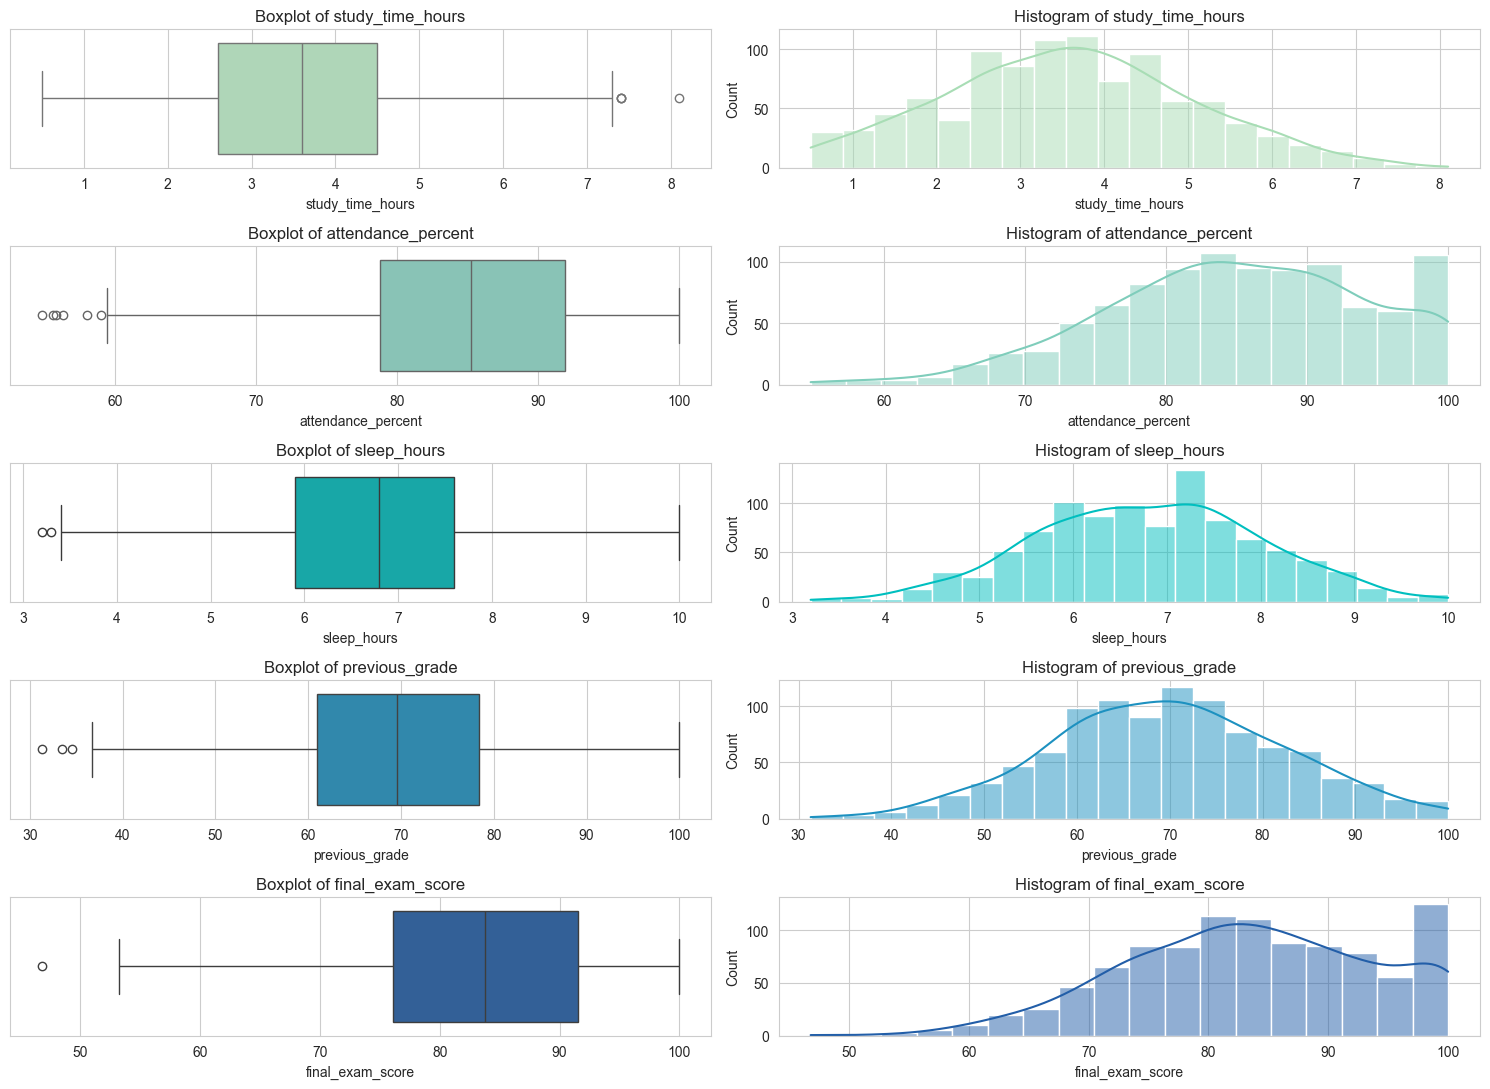

In [18]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 11), tight_layout=True)

sns.boxplot(x=df_etl["study_time_hours"], ax=axes[0,0], color="#A8DDB5")
axes[0,0].set_title("Boxplot of study_time_hours")

sns.histplot(x=df_etl["study_time_hours"], ax=axes[0,1], kde=True, color="#A8DDB5")
axes[0,1].set_title("Histogram of study_time_hours")

sns.boxplot(x=df_etl["attendance_percent"], ax=axes[1,0], color="#7FCDBB")
axes[1,0].set_title("Boxplot of attendance_percent")

sns.histplot(x=df_etl["attendance_percent"], ax=axes[1,1], kde=True, color="#7FCDBB")
axes[1,1].set_title("Histogram of attendance_percent")

sns.boxplot(x=df_etl["sleep_hours"], ax=axes[2,0], color="c")
axes[2,0].set_title("Boxplot of sleep_hours")

sns.histplot(x=df_etl["sleep_hours"], ax=axes[2,1], kde=True, color="c")
axes[2,1].set_title("Histogram of sleep_hours")

sns.boxplot(x=df_etl["previous_grade"], ax=axes[3,0], color="#1D91C0")
axes[3,0].set_title("Boxplot of previous_grade")

sns.histplot(x=df_etl["previous_grade"], ax=axes[3,1], kde=True, color="#1D91C0")
axes[3,1].set_title("Histogram of previous_grade")

sns.boxplot(x=df_etl["final_exam_score"], ax=axes[4,0], color="#225EA8")
axes[4,0].set_title("Boxplot of final_exam_score")

sns.histplot(x=df_etl["final_exam_score"], ax=axes[4,1], kde=True, color="#225EA8")
axes[4,1].set_title("Histogram of final_exam_score")

plt.show()

> *Notes on Process*:
<br><br>In future, I would like to get more confident in looping over variables to create multiple graphs, rather than spelling out each one individually as I have done above.

#### **2.3.2 Interquartile Range Investigation**

Beyond visualising this data in the boxplots above, I want to see more granular detail about the interquartile ranges and the upper and lower bounds of each numeric column.

> *Notes on Process*:
<br><br>The below method was outlined to us by Rory from Code Institute.

##### **Study Time Hours**

In this section, I am going to explore `study_time_hours` in more detail. Firstly, I will create a write-up of what we have already seen in the boxplots (but that will give more exact figures than reading the plots).

In [19]:
# Establish the Interquartile Range for study_time_hours
Q1 = df_etl["study_time_hours"].quantile(0.25)
Q3 = df_etl["study_time_hours"].quantile(0.75)
IQR = Q3 - Q1
print("="*50)
print(f"INTERQUARTILE RANGE ANALYSIS FOR STUDY TIME HOURS")
print("="*50)
print(f"Q1 for study_time_hours: {Q1}")
print(f"Q3 for study_time_hours: {Q3}")
print(f"IQR for study_time_hours: {IQR}")
print("-"*50)

# Calculate the upper and lower bounds for study_time_hours
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for study_time_hours: {upper_bound:.2f}")
print(f"Lower Bound for study_time_hours: {lower_bound:.2f}")

INTERQUARTILE RANGE ANALYSIS FOR STUDY TIME HOURS
Q1 for study_time_hours: 2.6
Q3 for study_time_hours: 4.5
IQR for study_time_hours: 1.9
--------------------------------------------------
Upper Bound for study_time_hours: 7.35
Lower Bound for study_time_hours: -0.25


As we can see from the above information, the lower bound is actually a negative number. This is because it is created using a statistical formula, rather than merely looking at the minimum value.

In [20]:
# Reminder of the minimum value for study_time_hours
print(f"Minimum value for study_time_hours: {df_etl['study_time_hours'].min()}")

Minimum value for study_time_hours: 0.5


Now we will look at the outliers: how many there are and what their values are.

In [21]:
# Review the outliers for study_time_hours
print("="*40)
print(f"OUTLIERS ANALYSIS FOR STUDY TIME HOURS")
print("="*40)

# Ascertain the number of outliers above the upper bound for study_time_hours
print(f"Outliers found above the upper bound: {(df_etl['study_time_hours'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for study_time_hours
print(f"Outliers found below the lower bound: {(df_etl['study_time_hours'] < lower_bound).sum()}")

OUTLIERS ANALYSIS FOR STUDY TIME HOURS
Outliers found above the upper bound: 4
Outliers found below the lower bound: 0


In [22]:
# Use value_counts() to display the outlier values and their frequencies for study_time_hours
print("="*50)
print(f"OUTLIER VALUES FOR STUDY TIME HOURS")
print("="*50)

outliers_above_upper_bound_study = df_etl[df_etl["study_time_hours"] > upper_bound]
print(f"Values for study_time_hours above the upper bound:\n{outliers_above_upper_bound_study['study_time_hours'].value_counts()}")

OUTLIER VALUES FOR STUDY TIME HOURS
Values for study_time_hours above the upper bound:
study_time_hours
7.4    3
8.1    1
Name: count, dtype: int64


*Should I Delete?*

In this case, I have decided not to delete the outliers. The rationale behind this is because I am looking to ascertain what factors lead to a student receiving a higher final exam score. If I remove the four outliers, I may be removing key information - we have four students who have studied for the most hours, we shoudl investigate whether they had higher final exam scores.

##### **Attendance Percentage**

In [23]:
# Establish the Interquartile Range for attendance_percent
Q1 = df_etl["attendance_percent"].quantile(0.25)
Q3 = df_etl["attendance_percent"].quantile(0.75)
IQR = Q3 - Q1
print("="*53)
print(f"INTERQUARTILE RANGE ANALYSIS FOR ATTENDANCE PERCENT")
print("="*53)
print(f"Q1 for attendance_percent: {Q1}")
print(f"Q3 for attendance_percent: {Q3}")
print(f"IQR for attendance_percent: {IQR:.2f}")
print("-"*53)

# Calculate the upper and lower bounds for attendance_percent
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for attendance_percent: {upper_bound:.2f}")
print(f"Lower Bound for attendance_percent: {lower_bound:.2f}")

INTERQUARTILE RANGE ANALYSIS FOR ATTENDANCE PERCENT
Q1 for attendance_percent: 78.8
Q3 for attendance_percent: 91.9
IQR for attendance_percent: 13.10
-----------------------------------------------------
Upper Bound for attendance_percent: 111.55
Lower Bound for attendance_percent: 59.15


Looking at these figures, `attendance_percent` has an upper bound that is impossible. You cannot have a percentage that is over 100%. 

And this is verified when we look at the maximum number for the student attendance percentage:

In [24]:
# Reminder of the maximum value for attendance_percent
print(f"Maximum value for attendance_percent: {df_etl['attendance_percent'].max()}")

Maximum value for attendance_percent: 100.0


We will look again at the outliers: how many there are and what their values are.

In [25]:
# Review the outliers for attendance_percent
print("="*42)
print(f"OUTLIERS ANALYSIS FOR ATTENDANCE PERCENT")
print("="*42)

# Ascertain the number of outliers above the upper bound for attendance_percent
print(f"Outliers found above the upper bound: {(df_etl['attendance_percent'] > upper_bound).sum()}")

# Ascertain the number of outliers below the lower bound for attendance_percent
print(f"Outliers found below the lower bound: {(df_etl['attendance_percent'] < lower_bound).sum()}")

OUTLIERS ANALYSIS FOR ATTENDANCE PERCENT
Outliers found above the upper bound: 0
Outliers found below the lower bound: 6


In [26]:
# Show values for attendance_percent that are below the lower bound
print("="*38)
print("OUTLIER VALUES FOR ATTENDANCE PERCENT")
print("="*38)
outliers_below_lower_bound_attendance = df_etl[df_etl["attendance_percent"] < lower_bound]
print(f"Values for attendance_percent below the lower bound:\n{outliers_below_lower_bound_attendance['attendance_percent'].value_counts()}")

OUTLIER VALUES FOR ATTENDANCE PERCENT
Values for attendance_percent below the lower bound:
attendance_percent
56.3    1
55.8    1
58.0    1
55.6    1
54.8    1
59.0    1
Name: count, dtype: int64


*Should I Delete?*

With a careful look at each of the values that are below the lower bound, there are no percentages here that appear to be wildly anomalous. Attendance is still above 50% and, as with `study_time_hours` it would be interesting to explore these particular students further and the relationship between `attendance_percent` and `final_exam_score`.

##### **Sleep Hours**

For `sleep_hours`, I will make my workings more concise (although they still follow the steps as above).

In [27]:
# Establish the Interquartile Range for sleep_hours
Q1 = df_etl["sleep_hours"].quantile(0.25)
Q3 = df_etl["sleep_hours"].quantile(0.75)
IQR = Q3 - Q1
print("="*45)
print(f"INTERQUARTILE RANGE ANALYSIS FOR SLEEP HOURS")
print("="*45)
print(f"Q1 for sleep_hours: {Q1}")
print(f"Q3 for sleep_hours: {Q3}")
print(f"IQR for sleep_hours: {IQR:.2f}")
print("-"*45)

# Calculate the upper and lower bounds for sleep_hours
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for sleep_hours: {upper_bound:.2f}")
print(f"Lower Bound for sleep_hours: {lower_bound:.2f}")
print("")

# Ascertain the number of outliers above the upper bound and below the lower bound for sleep_hours
print("="*45)
print(f"OUTLIERS ANALYSIS FOR SLEEP HOURS")
print("="*45)
print(f"Outliers found above the upper bound: {(df_etl['sleep_hours'] > upper_bound).sum()}")
print(f"Outliers found below the lower bound: {(df_etl['sleep_hours'] < lower_bound).sum()}")
print("")

# Show values for sleep_hours that are below the lower bound
print("="*45)
print("OUTLIER VALUES FOR SLEEP HOURS")
print("="*45)
outliers_below_lower_bound_sleep = df_etl[df_etl["sleep_hours"] < lower_bound]
print(f"Values for sleep_hours below the lower bound:\n{outliers_below_lower_bound_sleep['sleep_hours'].value_counts()}")

INTERQUARTILE RANGE ANALYSIS FOR SLEEP HOURS
Q1 for sleep_hours: 5.9
Q3 for sleep_hours: 7.6
IQR for sleep_hours: 1.70
---------------------------------------------
Upper Bound for sleep_hours: 10.15
Lower Bound for sleep_hours: 3.35

OUTLIERS ANALYSIS FOR SLEEP HOURS
Outliers found above the upper bound: 0
Outliers found below the lower bound: 2

OUTLIER VALUES FOR SLEEP HOURS
Values for sleep_hours below the lower bound:
sleep_hours
3.2    1
3.3    1
Name: count, dtype: int64


*Should I Delete?*

I decided against deleting these two outliers, as I do not feel them to be significant enough to massively skew the distribution for `sleep_time_hours`.

##### **Previous Grade and Exam Score**

I have decided to combine my analysis of `previous_grade` and `final_exam_score` given that they both have the same output (in terms of unit/ what they are showing) - although, of course, they have different results.

In [28]:
# Establish the Interquartile Range for previous_grade
Q1 = df_etl["previous_grade"].quantile(0.25)
Q3 = df_etl["previous_grade"].quantile(0.75)
IQR = Q3 - Q1
print("="*50)
print(f"INTERQUARTILE RANGE ANALYSIS FOR PREVIOUS GRADE")
print("="*50)
print(f"Q1 for previous_grade: {Q1}")
print(f"Q3 for previous_grade: {Q3}")
print(f"IQR for previous_grade: {IQR:.2f}")
print("-"*50)

# Calculate the upper and lower bounds for previous_grade
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for previous_grade: {upper_bound:.2f}")
print(f"Lower Bound for previous_grade: {lower_bound:.2f}")
print("")

# Establish the Interquartile Range for final_exam_score
Q1 = df_etl["final_exam_score"].quantile(0.25)
Q3 = df_etl["final_exam_score"].quantile(0.75)
IQR = Q3 - Q1
print("="*50)
print(f"INTERQUARTILE RANGE ANALYSIS FOR FINAL EXAM SCORE")
print("="*50)
print(f"Q1 for final_exam_score: {Q1:.2f}")
print(f"Q3 for final_exam_score: {Q3:.2f}")
print(f"IQR for final_exam_score: {IQR:.2f}")
print("-"*50)

# Calculate the upper and lower bounds for final_exam_score
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Upper Bound for final_exam_score: {upper_bound:.2f}")
print(f"Lower Bound for final_exam_score: {lower_bound:.2f}")

INTERQUARTILE RANGE ANALYSIS FOR PREVIOUS GRADE
Q1 for previous_grade: 61.0
Q3 for previous_grade: 78.4
IQR for previous_grade: 17.40
--------------------------------------------------
Upper Bound for previous_grade: 104.50
Lower Bound for previous_grade: 34.90

INTERQUARTILE RANGE ANALYSIS FOR FINAL EXAM SCORE
Q1 for final_exam_score: 76.07
Q3 for final_exam_score: 91.53
IQR for final_exam_score: 15.45
--------------------------------------------------
Upper Bound for final_exam_score: 114.70
Lower Bound for final_exam_score: 52.90


In both cases, we see that the upper bound goes above the maximum possible score (100.00). However, as we have seen before, this does not mean that the maximum values in these two columns will go above 100.00.

In [29]:
# Ascertain the number of outliers above the upper bound and below the lower bound for previous_grade
print("="*45)
print(f"OUTLIERS FOR PREVIOUS GRADE")
print("="*45)
print(f"Outliers found above the upper bound: {(df_etl['previous_grade'] > upper_bound).sum()}")
print(f"Outliers found below the lower bound: {(df_etl['previous_grade'] < lower_bound).sum()}")
print("")

# Ascertain the number of outliers above the upper bound and below the lower bound for final_exam_score
print("="*45)
print(f"OUTLIERS FOR FINAL EXAM SCORE")
print("="*45)
print(f"Outliers found above the upper bound: {(df_etl['final_exam_score'] > upper_bound).sum()}")
print(f"Outliers found below the lower bound: {(df_etl['final_exam_score'] < lower_bound).sum()}")

OUTLIERS FOR PREVIOUS GRADE
Outliers found above the upper bound: 0
Outliers found below the lower bound: 89

OUTLIERS FOR FINAL EXAM SCORE
Outliers found above the upper bound: 0
Outliers found below the lower bound: 1


I will not focus on `final_exam_score` here because there is only one outlier below the lower bound. I will **not** be deleting this outlier. 

I will, however, take a look at `previous_grade`, where there are 89 outliers. This is much more significant than any of the other outliers in terms of how many there are and it will be good to get a sense of what they are. 

In [30]:
# Show values for previous_grade that are below the lower bound
outliers_below_lower_bound_grade = df_etl[df_etl["previous_grade"] < lower_bound]
print("="*34)
print(f"RANGE OF PREVIOUS GRADE OUTLIERS")
print("="*34)
print(f"Minimum outlier value: {outliers_below_lower_bound_grade['previous_grade'].min()}")
print(f"Maximum outlier value: {outliers_below_lower_bound_grade['previous_grade'].max()}")
print(f"Range of outlier values: {outliers_below_lower_bound_grade['previous_grade'].max() - outliers_below_lower_bound_grade['previous_grade'].min():.2f}")

RANGE OF PREVIOUS GRADE OUTLIERS
Minimum outlier value: 31.3
Maximum outlier value: 52.8
Range of outlier values: 21.50


*Should I Delete?*

Some questions I need to ask myself before deciding on whether to remove these outliers.

1. Are the values plausible and are there any anomalies?<br>
Judging from the range of the outliers, all of these represent potential grade scores that a student could reasonably get.
There are also no dramatically different values listed (e.g. nothing as a minus number) and the range of these outliers is not massive (21.50 points)

2. What am I using the data for?<br>
Because I am going to be looking at factors that are associated with `final_exam_score`, removing the outlier students who performed poorly on the previous exam will remove an important group of students. It will potentially bias my analysis as I move on to the next stages of this project.

As a result, my decision is **not** to remove these outliers.

### **2.3 Feature Engineering**

I want to create a new feature column, `final_grade_category`, to map `A` and `B` grades to `High Grade` and `C`, `D` and `F` grades to `Low Grade`.

I will then encode these new values: `Low Grade` as `0` and `High Grade` as `1`. 

In both instances, I will use `.map()` to control which value is listed as which number. 

In [31]:
# Create a map of grades to categories in a new columm
df_etl["final_grade_category"] = df_etl["final_grade"].map({
    "A": "High Grade",
     "B": "High Grade",
     "C": "Low Grade",
     "D": "Low Grade",
     "F": "Low Grade"
})

# Validate the new column has been created using .head() to display the first few rows of the dataset
df_etl.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,final_grade_category
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A,High Grade
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A,High Grade
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A,High Grade
3,4,Male,2.6,77.5,8.0,Unknown,Yes,Yes,No,85.1,83.8,B,High Grade
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D,Low Grade


In [32]:
# Create a binary column for high and low grades using .map()
df_etl["final_grade_binary"] = df_etl["final_grade_category"].map({
    "High Grade": 1,
    "Low Grade": 0
})

# Validate the new column has been created using .head() to display the first few rows of the dataset
df_etl.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,final_grade_category,final_grade_binary
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A,High Grade,1
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A,High Grade,1
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A,High Grade,1
3,4,Male,2.6,77.5,8.0,Unknown,Yes,Yes,No,85.1,83.8,B,High Grade,1
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D,Low Grade,0


In [34]:
# Check the unique values in the two newly created columns
print(f"Unique values in final_grade_category: {df_etl['final_grade_category'].unique()}")
print(f"Unique values in final_grade_binary: {df_etl['final_grade_binary'].unique()}")

Unique values in final_grade_category: ['High Grade' 'Low Grade']
Unique values in final_grade_binary: [1 0]


> *Notes on Process*:
<br><br>I thought about using `OneHotEncode` at this stage of the project on all of my categorical columns, as I know that this is a very important step particularly when it comes to machine learning.
<br><br>My rationale for not doing so here is because I knew that I was going to use this as a preprocessing step in the creation of my machine learning pipelines for each of the algorithms I was testing.

---